In [1]:

import numpy as np
import pandas as pd
import pickle
from scipy.stats import entropy
import warnings
warnings.filterwarnings('ignore')

# Load the N=10^7 detailed results
df_n7 = pd.read_csv('N10^7_detailed_results.csv')
print("N=10^7 detailed results:")
print(df_n7)
print("\n" + "="*80 + "\n")

# Load omega values for N=10^6
with open('omega_values_N1e6.pkl', 'rb') as f:
 omega_values_1e6 = pickle.load(f)
print(f"Loaded omega values for N=10^6: shape = {omega_values_1e6.shape}")
print(f"Sample omega values (first 20): {omega_values_1e6[:20]}")


N=10^7 detailed results:
 Function N t_value peak_height r_value
0 Zeta 10000000 1.848485e+07 16.508561 0.780727
1 Zeta 10000000 1.232323e+07 10.284027 0.631713
2 Zeta 10000000 1.090909e+07 6.367052 -0.074793
3 Zeta 10000000 1.616162e+07 5.935386 1.437305
4 Zeta 10000000 1.191919e+07 5.878669 0.669312
5 Liouville 10000000 1.979798e+07 21.827989 1.924900
6 Liouville 10000000 1.787879e+07 17.305548 1.181383
7 Liouville 10000000 1.363636e+07 12.219003 1.787888
8 Liouville 10000000 1.929293e+07 9.473383 -0.345984
9 Liouville 10000000 1.212121e+07 7.941801 0.850410


Loaded omega values for N=10^6: shape = (1000000,)
Sample omega values (first 20): [0 1 1 2 1 2 1 3 2 2 1 3 1 2 2 4 1 3 1 3]


In [2]:

# Extract Liouville peak locations at N=10^7
liouville_n7 = df_n7[df_n7['Function'] == 'Liouville'].copy()
liouville_n7 = liouville_n7.sort_values('peak_height', ascending=False)
print("Liouville peaks at N=10^7 (sorted by peak height):")
print(liouville_n7[['t_value', 'peak_height', 'r_value']])
print()

# Extract t-values for N=10^7 analysis
t_values_n7 = liouville_n7['t_value'].values
print(f"T-values for N=10^7 analysis: {t_values_n7}")


Liouville peaks at N=10^7 (sorted by peak height):
 t_value peak_height r_value
5 1.979798e+07 21.827989 1.924900
6 1.787879e+07 17.305548 1.181383
7 1.363636e+07 12.219003 1.787888
8 1.929293e+07 9.473383 -0.345984
9 1.212121e+07 7.941801 0.850410

T-values for N=10^7 analysis: [19797979.7979798 17878787.87878788 13636363.63636364 19292929.29292929
 12121212.12121212]


In [3]:

# Generate omega values for N=10^7
# This will take significant time, but is necessary for the analysis
print("Generating omega values for N=10^7...")
print("This is a computationally expensive operation and will take several minutes.")

def compute_omega_values(N):
 """
 Compute Ω(n) for all n from 1 to N.
 Ω(n) is the number of prime factors with multiplicity.
 Uses 0-based indexing: omega_values[i] = Ω(i+1).
 """
 omega = np.zeros(N, dtype=np.int32)
 
 # Sieve-like approach
 for p in range(2, N + 1):
 if omega[p - 1] == 0: # p is prime (omega[p-1] was not set by smaller primes)
 # p is prime - set omega[p-1] = 1
 omega[p - 1] = 1
 
 # For all multiples of p
 power = p
 while power <= N:
 # Find all multiples of p^k
 idx = power
 while idx <= N:
 omega[idx - 1] += 1
 idx += power
 
 # Check if next power will overflow
 if power > N // p:
 break
 power *= p
 
 return omega

# Compute omega values for N=10^7
N_7 = 10**7
omega_values_1e7 = compute_omega_values(N_7)

print(f"Completed! Shape: {omega_values_1e7.shape}")
print(f"Sample omega values (first 20): {omega_values_1e7[:20]}")
print(f"Sample omega values (last 20): {omega_values_1e7[-20:]}")
print(f"Max omega value: {np.max(omega_values_1e7)}")
print(f"Mean omega value: {np.mean(omega_values_1e7):.4f}")


Generating omega values for N=10^7...
This is a computationally expensive operation and will take several minutes.


Completed! Shape: (10000000,)
Sample omega values (first 20): [0 2 2 2 2 2 2 3 2 2 2 3 2 2 2 4 2 3 2 3]
Sample omega values (last 20): [ 4 3 3 6 3 4 4 3 2 9 2 4 2 3 4 5 2 2 4 14]
Max omega value: 23
Mean omega value: 3.8526


In [4]:

# There's an issue with my omega computation - the first values should be [0,1,1,2,1,2,1,3,2,2,1,3,...]
# Let me fix this with a cleaner sieve implementation

def compute_omega_values_correct(N):
 """
 Compute Ω(n) for all n from 1 to N using prime factorization count with multiplicity.
 Uses 0-based indexing: omega_values[i] = Ω(i+1).
 """
 omega = np.zeros(N, dtype=np.int32)
 
 # Sieve approach: for each prime p, mark all its multiples
 for p in range(2, N + 1):
 if p * p > N:
 # For remaining numbers that haven't been fully factored, they are prime
 for n in range(p, N + 1):
 if omega[n - 1] == 0 and n > 1:
 omega[n - 1] = 1
 break
 
 # Check if p is prime by trying small factor division
 is_prime = True
 for test in range(2, int(p**0.5) + 1):
 if p % test == 0:
 is_prime = False
 break
 
 if is_prime:
 # For each power of p
 pk = p
 while pk <= N:
 # Add 1 to omega for all multiples of pk
 for multiple in range(pk, N + 1, pk):
 omega[multiple - 1] += 1
 
 # Next power
 if pk > N // p:
 break
 pk *= p
 
 return omega

# Actually, let me use a simpler and more efficient approach
def compute_omega_sieve(N):
 """
 Compute Ω(n) for all n from 1 to N.
 Uses efficient sieve: for each prime p, increment omega for all multiples of p^k.
 Uses 0-based indexing: omega_values[i] = Ω(i+1).
 """
 omega = np.zeros(N, dtype=np.int32)
 
 for p in range(2, N + 1):
 # Increment for all multiples of p (this adds 1 for each factor of p)
 for multiple in range(p, N + 1, p):
 # Count how many times p divides this multiple
 temp = multiple
 while temp % p == 0:
 omega[multiple - 1] += 1
 temp //= p
 
 return omega

print("Computing omega values with corrected algorithm...")
omega_values_1e7 = compute_omega_sieve(N_7)

print(f"Shape: {omega_values_1e7.shape}")
print(f"First 20 values: {omega_values_1e7[:20]}")
print(f"Expected: [0, 1, 1, 2, 1, 2, 1, 3, 2, 2, 1, 3, 1, 2, 2, 4, 1, 3, 1, 3]")
print(f"Match: {np.array_equal(omega_values_1e7[:20], np.array([0, 1, 1, 2, 1, 2, 1, 3, 2, 2, 1, 3, 1, 2, 2, 4, 1, 3, 1, 3]))}")


Computing omega values with corrected algorithm...


Shape: (10000000,)
First 20 values: [0 1 1 3 1 3 1 5 3 3 1 6 1 3 3 8 1 6 1 6]
Expected: [0, 1, 1, 2, 1, 2, 1, 3, 2, 2, 1, 3, 1, 2, 2, 4, 1, 3, 1, 3]
Match: False


In [5]:

# I see the issue - I'm counting p multiple times for p^k. Let me use the standard sieve approach.

def compute_omega_correct(N):
 """
 Compute Ω(n) = number of prime factors with multiplicity for n=1 to N.
 Uses 0-based indexing: result[i] = Ω(i+1).
 
 Algorithm: For each number, count prime factors with multiplicity.
 """
 omega = np.zeros(N, dtype=np.int32)
 
 # For each potential prime
 for p in range(2, N + 1):
 # For each multiple of p, count how many times p divides it
 for n in range(p, N + 1, p):
 temp = n
 while temp % p == 0:
 omega[n - 1] += 1
 temp //= p
 
 # Early termination: if p^2 > N, remaining numbers > p are either prime or already processed
 if p * p > N:
 break
 
 # Handle remaining numbers that are prime
 for n in range(2, N + 1):
 if omega[n - 1] == 0:
 omega[n - 1] = 1
 
 return omega

# This is still inefficient. Let me use the standard optimized sieve.
def compute_omega_optimized(N):
 """
 Optimized computation of Ω(n) using modified sieve.
 Uses 0-based indexing: result[i] = Ω(i+1).
 """
 omega = np.zeros(N, dtype=np.int32)
 smallest_prime_factor = np.zeros(N, dtype=np.int32)
 
 # Sieve to find smallest prime factor
 for i in range(2, N + 1):
 if smallest_prime_factor[i - 1] == 0: # i is prime
 for j in range(i, N + 1, i):
 if smallest_prime_factor[j - 1] == 0:
 smallest_prime_factor[j - 1] = i
 
 # Compute omega using smallest prime factor
 for n in range(2, N + 1):
 temp = n
 while temp > 1:
 p = smallest_prime_factor[temp - 1]
 omega[n - 1] += 1
 temp //= p
 
 return omega

print("Computing omega values with optimized sieve...")
omega_values_1e7 = compute_omega_optimized(N_7)

print(f"Shape: {omega_values_1e7.shape}")
print(f"First 20 values: {omega_values_1e7[:20]}")
print(f"Expected: [0, 1, 1, 2, 1, 2, 1, 3, 2, 2, 1, 3, 1, 2, 2, 4, 1, 3, 1, 3]")
print(f"Match: {np.array_equal(omega_values_1e7[:20], np.array([0, 1, 1, 2, 1, 2, 1, 3, 2, 2, 1, 3, 1, 2, 2, 4, 1, 3, 1, 3]))}")


Computing omega values with optimized sieve...


Shape: (10000000,)
First 20 values: [0 1 1 2 1 2 1 3 2 2 1 3 1 2 2 4 1 3 1 3]
Expected: [0, 1, 1, 2, 1, 2, 1, 3, 2, 2, 1, 3, 1, 2, 2, 4, 1, 3, 1, 3]
Match: True


In [6]:

# Great! Now verify consistency with N=10^6 omega values
print("Verifying consistency with loaded N=10^6 omega values:")
print(f"Match for first 1M values: {np.array_equal(omega_values_1e7[:1000000], omega_values_1e6)}")
print(f"Max omega at N=10^7: {np.max(omega_values_1e7)}")
print(f"Mean omega at N=10^7: {np.mean(omega_values_1e7):.4f}")

# Save omega values for N=10^7 for future use
with open('omega_values_N1e7.pkl', 'wb') as f:
 pickle.dump(omega_values_1e7, f)
print("Saved omega_values_N1e7.pkl")


Verifying consistency with loaded N=10^6 omega values:
Match for first 1M values: True
Max omega at N=10^7: 23
Mean omega at N=10^7: 3.7861
Saved omega_values_N1e7.pkl


In [7]:

# Now generate Liouville coefficients for N=10^7
# Liouville function: λ(n) = (-1)^Ω(n)

def generate_liouville_coefficients(N, omega_values):
 """
 Generate Liouville function coefficients.
 λ(n) = (-1)^Ω(n)
 
 Parameters:
 -----------
 N : int
 Number of coefficients
 omega_values : ndarray
 Pre-computed Ω(n) values (0-indexed: omega_values[i] = Ω(i+1))
 
 Returns:
 --------
 ndarray of complex coefficients
 """
 return np.array([(-1)**omega_values[i] for i in range(N)], dtype=np.complex128)

print("Generating Liouville coefficients for N=10^7...")
liouville_coeffs_1e7 = generate_liouville_coefficients(N_7, omega_values_1e7)

print(f"Shape: {liouville_coeffs_1e7.shape}")
print(f"First 20 coefficients: {liouville_coeffs_1e7[:20]}")
print(f"All coefficients real: {np.all(np.imag(liouville_coeffs_1e7) == 0)}")
print(f"All coefficients in {{-1, 1}}: {np.all(np.abs(liouville_coeffs_1e7) == 1)}")
print(f"Mean coefficient: {np.mean(liouville_coeffs_1e7.real):.6f}")


Generating Liouville coefficients for N=10^7...


Shape: (10000000,)
First 20 coefficients: [ 1.+0.j -1.+0.j -1.+0.j 1.+0.j -1.+0.j 1.+0.j -1.+0.j -1.+0.j 1.+0.j
 1.+0.j -1.+0.j -1.+0.j -1.+0.j 1.+0.j 1.+0.j 1.+0.j -1.+0.j -1.+0.j
 -1.+0.j -1.+0.j]
All coefficients real: True
All coefficients in {-1, 1}: True
Mean coefficient: -0.000084


In [8]:

# Now define the function to compute Dirichlet sum with Kahan summation
def kahan_dirichlet_sum(coeffs, t, N):
 """
 Compute Dirichlet sum D(t; N) = Σ_{n=1}^N a_n / n^(1/2 + it)
 using Kahan compensated summation for numerical precision.
 
 Parameters:
 -----------
 coeffs : ndarray
 Coefficient array (0-indexed: coeffs[i] = a_{i+1})
 t : float
 Evaluation point
 N : int
 Truncation parameter
 
 Returns:
 --------
 complex
 The Dirichlet sum D(t; N)
 """
 total = 0.0 + 0.0j
 c = 0.0 + 0.0j # Running compensation
 
 for n in range(1, N + 1):
 # Compute term
 term = coeffs[n - 1] / (n ** (0.5 + 1j * t))
 
 # Kahan summation
 y = term - c
 temp = total + y
 c = (temp - total) - y
 total = temp
 
 return total

print("Testing Kahan summation with small N...")
test_t = 1000.0
test_N = 1000
test_sum = kahan_dirichlet_sum(liouville_coeffs_1e7[:test_N], test_t, test_N)
print(f"D_Liouville(t={test_t}, N={test_N}) = {test_sum}")
print(f"|D| = {np.abs(test_sum):.6f}")


Testing Kahan summation with small N...
D_Liouville(t=1000.0, N=1000) = (0.5743635181570705+0.05857037830002389j)
|D| = 0.577342


In [9]:

# Now we need to compute omega-class decompositions S_k at each peak
# S_k(t) = Σ_{n: Ω(n)=k} a_n / n^(1/2 + it)

def compute_omega_decomposition_kahan(coeffs, omega_values, t, N, max_k=15):
 """
 Compute ω-class decomposition S_k(t) for k=0 to max_k.
 Uses Kahan summation for each class.
 
 Parameters:
 -----------
 coeffs : ndarray
 Coefficient array (0-indexed)
 omega_values : ndarray 
 Ω(n) values (0-indexed: omega_values[i] = Ω(i+1))
 t : float
 Evaluation point
 N : int
 Truncation
 max_k : int
 Maximum ω-class to compute
 
 Returns:
 --------
 dict : {k: S_k} for k=0 to max_k
 """
 S = {}
 
 for k in range(max_k + 1):
 total = 0.0 + 0.0j
 c = 0.0 + 0.0j
 
 for n in range(1, N + 1):
 if omega_values[n - 1] == k:
 term = coeffs[n - 1] / (n ** (0.5 + 1j * t))
 y = term - c
 temp = total + y
 c = (temp - total) - y
 total = temp
 
 S[k] = total
 
 return S

print("Testing omega decomposition at small N...")
test_decomp = compute_omega_decomposition_kahan(
 liouville_coeffs_1e7[:test_N], 
 omega_values_1e7[:test_N], 
 test_t, 
 test_N,
 max_k=10
)

print("\nOmega-class decomposition:")
for k, s_k in sorted(test_decomp.items()):
 print(f" S_{k} = {s_k:.6f}, |S_{k}| = {np.abs(s_k):.6f}")

# Verify total
total_from_classes = sum(test_decomp.values())
print(f"\nSum of S_k: {total_from_classes}")
print(f"Direct sum: {test_sum}")
print(f"Match: {np.allclose(total_from_classes, test_sum)}")


Testing omega decomposition at small N...

Omega-class decomposition:
 S_0 = 1.000000+0.000000j, |S_0| = 1.000000
 S_1 = 0.194132-0.725155j, |S_1| = 0.750691
 S_2 = -0.350467+0.431128j, |S_2| = 0.555607
 S_3 = 0.062512+0.198486j, |S_3| = 0.208098
 S_4 = -0.213249-0.015309j, |S_4| = 0.213798
 S_5 = -0.082465+0.065228j, |S_5| = 0.105144
 S_6 = 0.027425+0.064808j, |S_6| = 0.070372
 S_7 = -0.066793+0.052489j, |S_7| = 0.084949
 S_8 = 0.003394-0.001743j, |S_8| = 0.003815
 S_9 = -0.000126-0.011363j, |S_9| = 0.011363
 S_10 = 0.000000+0.000000j, |S_10| = 0.000000

Sum of S_k: (0.5743635181570704+0.05857037830002384j)
Direct sum: (0.5743635181570705+0.05857037830002389j)
Match: True


In [10]:

# Excellent! Now let's compute the omega decompositions at N=10^7 peaks
# This will be computationally expensive, so we'll use a progress indicator

def analyze_peak_power_distribution(coeffs, omega_values, t, N, max_k=15):
 """
 Analyze power distribution across ω-classes at a given peak.
 
 Returns:
 --------
 dict with keys:
 - 'S_k': dict of {k: S_k} values
 - 'P_k': dict of {k: |S_k|²} values 
 - 'total_power': Σ|S_k|²
 - 'entropy': Shannon entropy of power distribution
 - 'variance_k_geq_4': Variance contributed by k≥4 classes
 - 'fraction_k_geq_4': Fraction of total variance from k≥4
 """
 # Compute omega decomposition
 S_k = compute_omega_decomposition_kahan(coeffs, omega_values, t, N, max_k)
 
 # Compute powers
 P_k = {k: np.abs(s)**2 for k, s in S_k.items()}
 total_power = sum(P_k.values())
 
 # Compute normalized power distribution (probabilities)
 p_k = np.array([P_k[k] / total_power for k in range(max_k + 1)])
 
 # Shannon entropy H = -Σ p_k log(p_k)
 # Use scipy.stats.entropy which handles zero probabilities correctly
 H = entropy(p_k, base=np.e)
 
 # Variance analysis
 # Variance of denominator Den = Σ P_k
 # We need to understand what "variance contributed by k≥4" means
 # In the context of power distribution, this likely means:
 # The sum of powers for k≥4 divided by total power
 
 power_k_geq_4 = sum(P_k[k] for k in range(4, max_k + 1))
 fraction_k_geq_4 = power_k_geq_4 / total_power
 
 return {
 'S_k': S_k,
 'P_k': P_k,
 'total_power': total_power,
 'entropy': H,
 'power_k_geq_4': power_k_geq_4,
 'fraction_k_geq_4': fraction_k_geq_4
 }

print("Computing power distribution analysis for N=10^7 peaks...")
print("This will take significant time (~several minutes per peak)...\n")

results_n7 = []
for i, t in enumerate(t_values_n7):
 print(f"Processing peak {i+1}/5 at t={t:.2e}...")
 result = analyze_peak_power_distribution(
 liouville_coeffs_1e7,
 omega_values_1e7,
 t,
 N_7,
 max_k=15
 )
 results_n7.append(result)
 print(f" Entropy: {result['entropy']:.6f}")
 print(f" Fraction k≥4: {result['fraction_k_geq_4']:.6f}")
 print()

print("Completed N=10^7 analysis!")


Computing power distribution analysis for N=10^7 peaks...
This will take significant time (~several minutes per peak)...

Processing peak 1/5 at t=1.98e+07...


 Entropy: 1.634242
 Fraction k≥4: 0.261623

Processing peak 2/5 at t=1.79e+07...


 Entropy: 1.919113
 Fraction k≥4: 0.398415

Processing peak 3/5 at t=1.36e+07...


 Entropy: 1.339980
 Fraction k≥4: 0.058102

Processing peak 4/5 at t=1.93e+07...


 Entropy: 1.624418
 Fraction k≥4: 0.136456

Processing peak 5/5 at t=1.21e+07...


 Entropy: 1.638573
 Fraction k≥4: 0.129903

Completed N=10^7 analysis!


In [11]:

# Now we need N=10^6 analysis for comparison
# First, generate Liouville coefficients for N=10^6

N_6 = 10**6
print("Generating Liouville coefficients for N=10^6...")
liouville_coeffs_1e6 = generate_liouville_coefficients(N_6, omega_values_1e6)
print(f"Shape: {liouville_coeffs_1e6.shape}")

# For N=10^6, we need to select 5 representative high-r peaks
# According to the dataset description, we need peaks in the range [N, 2N] = [10^6, 2*10^6]
# Let's search for peaks in this range

print("\nSearching for high-magnitude peaks at N=10^6 in range [1e6, 2e6]...")
print("Using coarse grid search as mentioned in dataset description...")

# Coarse grid search with 2000 points
t_min_6 = N_6
t_max_6 = 2 * N_6
n_grid = 2000
t_grid_6 = np.linspace(t_min_6, t_max_6, n_grid)

print(f"Evaluating Dirichlet sums at {n_grid} grid points...")
magnitudes_6 = []

for i, t in enumerate(t_grid_6):
 if i % 200 == 0:
 print(f" Progress: {i}/{n_grid}")
 
 D = kahan_dirichlet_sum(liouville_coeffs_1e6, t, N_6)
 magnitudes_6.append(np.abs(D))

magnitudes_6 = np.array(magnitudes_6)
print(f"Completed grid evaluation!")
print(f"Max magnitude: {np.max(magnitudes_6):.6f}")
print(f"Mean magnitude: {np.mean(magnitudes_6):.6f}")


TimeoutError: Code execution timed out after 1200 seconds

In [12]:

# The computation is taking too long. Let me use vectorized computation instead of Kahan summation
# for the peak search at N=10^6, then use Kahan for final analysis

N_6 = 10**6
print("Generating Liouville coefficients for N=10^6...")
liouville_coeffs_1e6 = generate_liouville_coefficients(N_6, omega_values_1e6)
print(f"Shape: {liouville_coeffs_1e6.shape}")

def vectorized_dirichlet_sum(coeffs, t, N):
 """Fast vectorized Dirichlet sum (less accurate but much faster for peak search)"""
 n = np.arange(1, N + 1)
 terms = coeffs / (n ** (0.5 + 1j * t))
 return np.sum(terms)

print("\nSearching for high-magnitude peaks at N=10^6...")
print("Using vectorized computation for speed (coarse grid with 1000 points)...")

t_min_6 = N_6
t_max_6 = 2 * N_6
n_grid = 1000
t_grid_6 = np.linspace(t_min_6, t_max_6, n_grid)

magnitudes_6 = np.array([np.abs(vectorized_dirichlet_sum(liouville_coeffs_1e6, t, N_6)) 
 for t in t_grid_6])

print(f"Completed grid evaluation!")
print(f"Max magnitude: {np.max(magnitudes_6):.6f}")
print(f"Mean magnitude: {np.mean(magnitudes_6):.6f}")


Generating Liouville coefficients for N=10^6...


Shape: (1000000,)



Searching for high-magnitude peaks at N=10^6...
Using vectorized computation for speed (coarse grid with 1000 points)...


Completed grid evaluation!
Max magnitude: 27.296378
Mean magnitude: 2.291782


In [13]:

# Find the top peaks and refine them
from scipy.optimize import minimize_scalar

# Find local maxima
peak_indices = []
for i in range(1, len(magnitudes_6) - 1):
 if magnitudes_6[i] > magnitudes_6[i-1] and magnitudes_6[i] > magnitudes_6[i+1]:
 peak_indices.append(i)

print(f"Found {len(peak_indices)} local maxima in coarse grid")

# Sort by magnitude and take top 10 for refinement
peak_magnitudes = [(i, magnitudes_6[i]) for i in peak_indices]
peak_magnitudes.sort(key=lambda x: x[1], reverse=True)

print("\nTop 10 coarse peaks:")
for i, (idx, mag) in enumerate(peak_magnitudes[:10]):
 print(f" {i+1}. t={t_grid_6[idx]:.2e}, |D|={mag:.6f}")

# Refine the top 5 peaks using local optimization
print("\nRefining top 5 peaks...")
refined_peaks_6 = []

for i, (idx, mag) in enumerate(peak_magnitudes[:5]):
 t_coarse = t_grid_6[idx]
 
 # Define negative magnitude function for minimization
 def neg_magnitude(t):
 return -np.abs(vectorized_dirichlet_sum(liouville_coeffs_1e6, t, N_6))
 
 # Refine within a narrow window
 window = (t_max_6 - t_min_6) / n_grid * 2
 result = minimize_scalar(neg_magnitude, 
 bounds=(t_coarse - window/2, t_coarse + window/2),
 method='bounded')
 
 t_refined = result.x
 mag_refined = -result.fun
 
 refined_peaks_6.append({'t': t_refined, 'magnitude': mag_refined})
 print(f" Peak {i+1}: t={t_refined:.6f}, |D|={mag_refined:.6f}")

# Extract t-values for N=10^6 analysis
t_values_n6 = np.array([p['t'] for p in refined_peaks_6])
print(f"\nT-values for N=10^6 analysis: {t_values_n6}")


Found 368 local maxima in coarse grid

Top 10 coarse peaks:
 1. t=1.28e+06, |D|=27.296378
 2. t=1.19e+06, |D|=27.203616
 3. t=1.93e+06, |D|=24.106918
 4. t=1.56e+06, |D|=20.849185
 5. t=1.57e+06, |D|=18.513634
 6. t=1.65e+06, |D|=18.197396
 7. t=1.04e+06, |D|=15.965001
 8. t=1.92e+06, |D|=15.909573
 9. t=1.57e+06, |D|=15.042577
 10. t=1.00e+06, |D|=14.537663

Refining top 5 peaks...


 Peak 1: t=1282518.371656, |D|=4.812846


 Peak 2: t=1193429.000400, |D|=6.610331


 Peak 3: t=1930124.369697, |D|=5.489124


 Peak 4: t=1562788.830763, |D|=12.441401


 Peak 5: t=1569317.299448, |D|=38.808407

T-values for N=10^6 analysis: [1282518.37165598 1193429.00040038 1930124.36969747 1562788.83076301
 1569317.29944764]


In [14]:

# The refinement seems to have issues - let me just use the coarse grid peaks directly
# and re-evaluate with Kahan summation

print("Using coarse grid peaks for N=10^6 analysis:")
t_values_n6 = np.array([t_grid_6[idx] for idx, mag in peak_magnitudes[:5]])

# Re-evaluate with Kahan summation for accuracy
for i, t in enumerate(t_values_n6):
 D = kahan_dirichlet_sum(liouville_coeffs_1e6, t, N_6)
 mag = np.abs(D)
 print(f" Peak {i+1}: t={t:.6f}, |D|={mag:.6f}")

print(f"\nT-values for N=10^6 analysis: {t_values_n6}")


Using coarse grid peaks for N=10^6 analysis:


 Peak 1: t=1282282.282282, |D|=27.296378


 Peak 2: t=1193193.193193, |D|=27.203616


 Peak 3: t=1929929.929930, |D|=24.106918


 Peak 4: t=1562562.562563, |D|=20.849185


 Peak 5: t=1569569.569570, |D|=18.513634

T-values for N=10^6 analysis: [1282282.28228228 1193193.19319319 1929929.92992993 1562562.56256256
 1569569.56956957]


In [15]:

# Now compute power distribution analysis for N=10^6 peaks
print("Computing power distribution analysis for N=10^6 peaks...")

results_n6 = []
for i, t in enumerate(t_values_n6):
 print(f"Processing peak {i+1}/5 at t={t:.2e}...")
 result = analyze_peak_power_distribution(
 liouville_coeffs_1e6,
 omega_values_1e6,
 t,
 N_6,
 max_k=15
 )
 results_n6.append(result)
 print(f" Entropy: {result['entropy']:.6f}")
 print(f" Fraction k≥4: {result['fraction_k_geq_4']:.6f}")
 print()

print("Completed N=10^6 analysis!")


Computing power distribution analysis for N=10^6 peaks...
Processing peak 1/5 at t=1.28e+06...


 Entropy: 1.796215
 Fraction k≥4: 0.406761

Processing peak 2/5 at t=1.19e+06...


 Entropy: 1.812720
 Fraction k≥4: 0.545875

Processing peak 3/5 at t=1.93e+06...


 Entropy: 1.675253
 Fraction k≥4: 0.290788

Processing peak 4/5 at t=1.56e+06...


 Entropy: 1.932902
 Fraction k≥4: 0.572233

Processing peak 5/5 at t=1.57e+06...


 Entropy: 1.641163
 Fraction k≥4: 0.234096

Completed N=10^6 analysis!


In [16]:

# Now compare the statistics between N=10^6 and N=10^7
import matplotlib.pyplot as plt

# Extract statistics
entropies_n6 = [r['entropy'] for r in results_n6]
entropies_n7 = [r['entropy'] for r in results_n7]

fractions_k4_n6 = [r['fraction_k_geq_4'] for r in results_n6]
fractions_k4_n7 = [r['fraction_k_geq_4'] for r in results_n7]

# Compute means and standard deviations
mean_entropy_n6 = np.mean(entropies_n6)
std_entropy_n6 = np.std(entropies_n6, ddof=1)
mean_entropy_n7 = np.mean(entropies_n7)
std_entropy_n7 = np.std(entropies_n7, ddof=1)

mean_frac_n6 = np.mean(fractions_k4_n6)
std_frac_n6 = np.std(fractions_k4_n6, ddof=1)
mean_frac_n7 = np.mean(fractions_k4_n7)
std_frac_n7 = np.std(fractions_k4_n7, ddof=1)

print("="*80)
print("COMPARISON OF POWER DISTRIBUTION STATISTICS")
print("="*80)
print("\n1. SHANNON ENTROPY OF POWER DISTRIBUTION")
print("-" * 80)
print(f"N=10^6: Mean = {mean_entropy_n6:.6f} ± {std_entropy_n6:.6f}")
print(f" Individual values: {[f'{e:.6f}' for e in entropies_n6]}")
print(f"\nN=10^7: Mean = {mean_entropy_n7:.6f} ± {std_entropy_n7:.6f}")
print(f" Individual values: {[f'{e:.6f}' for e in entropies_n7]}")
print(f"\nChange: Δ = {mean_entropy_n7 - mean_entropy_n6:.6f} ({(mean_entropy_n7/mean_entropy_n6 - 1)*100:.2f}%)")

print("\n2. FRACTION OF POWER IN k≥4 CLASSES")
print("-" * 80)
print(f"N=10^6: Mean = {mean_frac_n6:.6f} ± {std_frac_n6:.6f}")
print(f" Individual values: {[f'{f:.6f}' for f in fractions_k4_n6]}")
print(f"\nN=10^7: Mean = {mean_frac_n7:.6f} ± {std_frac_n7:.6f}")
print(f" Individual values: {[f'{f:.6f}' for f in fractions_k4_n7]}")
print(f"\nChange: Δ = {mean_frac_n7 - mean_frac_n6:.6f} ({(mean_frac_n7/mean_frac_n6 - 1)*100:.2f}%)")

print("\n" + "="*80)


COMPARISON OF POWER DISTRIBUTION STATISTICS

1. SHANNON ENTROPY OF POWER DISTRIBUTION
--------------------------------------------------------------------------------
N=10^6: Mean = 1.771650 ± 0.116846
 Individual values: ['1.796215', '1.812720', '1.675253', '1.932902', '1.641163']

N=10^7: Mean = 1.631265 ± 0.204825
 Individual values: ['1.634242', '1.919113', '1.339980', '1.624418', '1.638573']

Change: Δ = -0.140385 (-7.92%)

2. FRACTION OF POWER IN k≥4 CLASSES
--------------------------------------------------------------------------------
N=10^6: Mean = 0.409950 ± 0.149955
 Individual values: ['0.406761', '0.545875', '0.290788', '0.572233', '0.234096']

N=10^7: Mean = 0.196900 ± 0.134354
 Individual values: ['0.261623', '0.398415', '0.058102', '0.136456', '0.129903']

Change: Δ = -0.213051 (-51.97%)



In [17]:

# This is very surprising! The result is the OPPOSITE of the hypothesis
# Let me examine the power distributions in more detail

print("DETAILED POWER DISTRIBUTIONS")
print("="*80)

print("\nN=10^6 PEAKS:")
print("-"*80)
for i, result in enumerate(results_n6):
 print(f"\nPeak {i+1} (t={t_values_n6[i]:.2e}):")
 P_k = result['P_k']
 total = result['total_power']
 
 # Print power for each class
 for k in range(10):
 frac = P_k[k] / total
 print(f" k={k}: P_k={P_k[k]:12.6f}, fraction={frac:.6f}")
 
 # Summary
 P_0_3 = sum(P_k[k] for k in range(4))
 P_4_plus = sum(P_k[k] for k in range(4, 16))
 print(f" k=0-3: {P_0_3/total:.6f}")
 print(f" k≥4: {P_4_plus/total:.6f}")
 print(f" Entropy: {result['entropy']:.6f}")

print("\n" + "="*80)
print("\nN=10^7 PEAKS:")
print("-"*80)
for i, result in enumerate(results_n7):
 print(f"\nPeak {i+1} (t={t_values_n7[i]:.2e}):")
 P_k = result['P_k']
 total = result['total_power']
 
 # Print power for each class
 for k in range(10):
 frac = P_k[k] / total
 print(f" k={k}: P_k={P_k[k]:12.6f}, fraction={frac:.6f}")
 
 # Summary
 P_0_3 = sum(P_k[k] for k in range(4))
 P_4_plus = sum(P_k[k] for k in range(4, 16))
 print(f" k=0-3: {P_0_3/total:.6f}")
 print(f" k≥4: {P_4_plus/total:.6f}")
 print(f" Entropy: {result['entropy']:.6f}")


DETAILED POWER DISTRIBUTIONS

N=10^6 PEAKS:
--------------------------------------------------------------------------------

Peak 1 (t=1.28e+06):
 k=0: P_k= 1.000000, fraction=0.005688
 k=1: P_k= 13.426957, fraction=0.076376
 k=2: P_k= 39.745502, fraction=0.226083
 k=3: P_k= 50.119332, fraction=0.285092
 k=4: P_k= 36.383975, fraction=0.206962
 k=5: P_k= 20.452616, fraction=0.116340
 k=6: P_k= 8.846557, fraction=0.050322
 k=7: P_k= 3.599318, fraction=0.020474
 k=8: P_k= 1.307025, fraction=0.007435
 k=9: P_k= 0.526999, fraction=0.002998
 k=0-3: 0.593239
 k≥4: 0.406761
 Entropy: 1.796215

Peak 2 (t=1.19e+06):
 k=0: P_k= 1.000000, fraction=0.003896
 k=1: P_k= 12.727496, fraction=0.049592
 k=2: P_k= 37.659109, fraction=0.146737
 k=3: P_k= 65.161750, fraction=0.253900
 k=4: P_k= 70.713150, fraction=0.275530
 k=5: P_k= 41.607710, fraction=0.162122
 k=6: P_k= 16.149531, fraction=0.062926
 k=7: P_k= 7.256576, fraction=0.028275
 k=8: P_k= 2.778771, fraction=0.010827
 k=9: P_k= 0.922278, fractio

In [18]:

# Let me check the r-values from the original data to understand the context better
print("R-VALUES FROM ORIGINAL DATA:")
print("="*80)

# From N10^7_detailed_results.csv
print("\nLiouville at N=10^7 (from file):")
for i, row in liouville_n7.iterrows():
 print(f" t={row['t_value']:.2e}: r={row['r_value']:.6f}, height={row['peak_height']:.6f}")

# Let me also compute the canonical r metric for these peaks to see if there's consistency
print("\n" + "="*80)
print("COMPUTING CANONICAL r METRIC")
print("="*80)

def compute_canonical_r(S_k_dict, max_k=15):
 """
 Compute canonical r metric:
 r = Σ_{j≠k} Re[S_j S̄_k] / Σ_k|S_k|²
 """
 # Numerator: sum of all cross terms Re[S_j * conj(S_k)] for j≠k
 numerator = 0.0
 for j in range(max_k + 1):
 for k in range(max_k + 1):
 if j != k:
 numerator += np.real(S_k_dict[j] * np.conj(S_k_dict[k]))
 
 # Denominator: sum of |S_k|²
 denominator = sum(np.abs(S_k_dict[k])**2 for k in range(max_k + 1))
 
 return numerator / denominator

print("\nN=10^6 peaks:")
r_values_n6 = []
for i, result in enumerate(results_n6):
 r = compute_canonical_r(result['S_k'])
 r_values_n6.append(r)
 print(f" Peak {i+1}: r = {r:.6f}")

print(f"\nMean r at N=10^6: {np.mean(r_values_n6):.6f} ± {np.std(r_values_n6, ddof=1):.6f}")

print("\nN=10^7 peaks:")
r_values_n7 = []
for i, result in enumerate(results_n7):
 r = compute_canonical_r(result['S_k'])
 r_values_n7.append(r)
 print(f" Peak {i+1}: r = {r:.6f}")

print(f"\nMean r at N=10^7: {np.mean(r_values_n7):.6f} ± {np.std(r_values_n7, ddof=1):.6f}")

print("\n" + "="*80)
print(f"Change in mean r: Δr = {np.mean(r_values_n7) - np.mean(r_values_n6):.6f}")
print(f"Relative change: {(np.mean(r_values_n7)/np.mean(r_values_n6) - 1)*100:.2f}%")


R-VALUES FROM ORIGINAL DATA:

Liouville at N=10^7 (from file):
 t=1.98e+07: r=1.924900, height=21.827989
 t=1.79e+07: r=1.181383, height=17.305548
 t=1.36e+07: r=1.787888, height=12.219003
 t=1.93e+07: r=-0.345984, height=9.473383
 t=1.21e+07: r=0.850410, height=7.941801

COMPUTING CANONICAL r METRIC

N=10^6 peaks:
 Peak 1: r = 3.227865
 Peak 2: r = 1.890393
 Peak 3: r = 2.540255
 Peak 4: r = 2.628963
 Peak 5: r = 4.946845

Mean r at N=10^6: 3.046864 ± 1.163122

N=10^7 peaks:
 Peak 1: r = 4.226128
 Peak 2: r = 5.918890
 Peak 3: r = 2.710302
 Peak 4: r = 1.759513
 Peak 5: r = 3.763081

Mean r at N=10^7: 3.675583 ± 1.576886

Change in mean r: Δr = 0.628719
Relative change: 20.63%


In [19]:

# The canonical r values I'm computing don't match the file values
# This is because the file values use a non-canonical formula (as warned in the description)
# My canonical values show an INCREASE in r from N=10^6 to N=10^7

# Let me perform statistical testing on the key findings

from scipy.stats import ttest_ind, mannwhitneyu

print("STATISTICAL SIGNIFICANCE TESTING")
print("="*80)

# Test 1: Entropy difference
print("\n1. Shannon Entropy")
print("-"*80)
t_stat_entropy, p_val_entropy = ttest_ind(entropies_n6, entropies_n7)
u_stat_entropy, p_val_entropy_mw = mannwhitneyu(entropies_n6, entropies_n7, alternative='two-sided')

print(f"N=10^6: {mean_entropy_n6:.6f} ± {std_entropy_n6:.6f}")
print(f"N=10^7: {mean_entropy_n7:.6f} ± {std_entropy_n7:.6f}")
print(f"Difference: {mean_entropy_n7 - mean_entropy_n6:.6f}")
print(f"t-test: t={t_stat_entropy:.4f}, p={p_val_entropy:.4f}")
print(f"Mann-Whitney U: U={u_stat_entropy:.1f}, p={p_val_entropy_mw:.4f}")

# Test 2: Fraction k≥4 difference
print("\n2. Fraction of Power in k≥4")
print("-"*80)
t_stat_frac, p_val_frac = ttest_ind(fractions_k4_n6, fractions_k4_n7)
u_stat_frac, p_val_frac_mw = mannwhitneyu(fractions_k4_n6, fractions_k4_n7, alternative='two-sided')

print(f"N=10^6: {mean_frac_n6:.6f} ± {std_frac_n6:.6f}")
print(f"N=10^7: {mean_frac_n7:.6f} ± {std_frac_n7:.6f}")
print(f"Difference: {mean_frac_n7 - mean_frac_n6:.6f}")
print(f"t-test: t={t_stat_frac:.4f}, p={p_val_frac:.4f}")
print(f"Mann-Whitney U: U={u_stat_frac:.1f}, p={p_val_frac_mw:.4f}")

# Test 3: Canonical r difference 
print("\n3. Canonical r Metric")
print("-"*80)
t_stat_r, p_val_r = ttest_ind(r_values_n6, r_values_n7)
u_stat_r, p_val_r_mw = mannwhitneyu(r_values_n6, r_values_n7, alternative='two-sided')

print(f"N=10^6: {np.mean(r_values_n6):.6f} ± {np.std(r_values_n6, ddof=1):.6f}")
print(f"N=10^7: {np.mean(r_values_n7):.6f} ± {np.std(r_values_n7, ddof=1):.6f}")
print(f"Difference: {np.mean(r_values_n7) - np.mean(r_values_n6):.6f}")
print(f"t-test: t={t_stat_r:.4f}, p={p_val_r:.4f}")
print(f"Mann-Whitney U: U={u_stat_r:.1f}, p={p_val_r_mw:.4f}")

print("\n" + "="*80)
print("NOTE: Small sample sizes (n=5 each) limit statistical power.")
print("Results should be interpreted with caution.")


STATISTICAL SIGNIFICANCE TESTING

1. Shannon Entropy
--------------------------------------------------------------------------------
N=10^6: 1.771650 ± 0.116846
N=10^7: 1.631265 ± 0.204825
Difference: -0.140385
t-test: t=1.3312, p=0.2198
Mann-Whitney U: U=21.0, p=0.0952

2. Fraction of Power in k≥4
--------------------------------------------------------------------------------
N=10^6: 0.409950 ± 0.149955
N=10^7: 0.196900 ± 0.134354
Difference: -0.213051
t-test: t=2.3661, p=0.0455
Mann-Whitney U: U=22.0, p=0.0556

3. Canonical r Metric
--------------------------------------------------------------------------------
N=10^6: 3.046864 ± 1.163122
N=10^7: 3.675583 ± 1.576886
Difference: 0.628719
t-test: t=-0.7175, p=0.4935
Mann-Whitney U: U=9.0, p=0.5476

NOTE: Small sample sizes (n=5 each) limit statistical power.
Results should be interpreted with caution.


In [20]:

# Let me create a comprehensive summary table
summary_data = {
 'N': ['10^6'] * 5 + ['10^7'] * 5,
 'Peak': list(range(1, 6)) + list(range(1, 6)),
 't_value': list(t_values_n6) + list(t_values_n7),
 'Entropy': entropies_n6 + entropies_n7,
 'Fraction_k>=4': fractions_k4_n6 + fractions_k4_n7,
 'Canonical_r': r_values_n6 + r_values_n7
}

df_summary = pd.DataFrame(summary_data)

print("COMPLETE ANALYSIS SUMMARY")
print("="*80)
print(df_summary.to_string(index=False))

# Compute group statistics
print("\n" + "="*80)
print("GROUP STATISTICS")
print("="*80)

stats_summary = df_summary.groupby('N').agg({
 'Entropy': ['mean', 'std'],
 'Fraction_k>=4': ['mean', 'std'],
 'Canonical_r': ['mean', 'std']
})

print(stats_summary)

# Save detailed results
df_summary.to_csv('power_distribution_analysis.csv', index=False)
print("\n" + "="*80)
print("Saved detailed results to: power_distribution_analysis.csv")


COMPLETE ANALYSIS SUMMARY
 N Peak t_value Entropy Fraction_k>=4 Canonical_r
10^6 1 1.282282e+06 1.796215 0.406761 3.227865
10^6 2 1.193193e+06 1.812720 0.545875 1.890393
10^6 3 1.929930e+06 1.675253 0.290788 2.540255
10^6 4 1.562563e+06 1.932902 0.572233 2.628963
10^6 5 1.569570e+06 1.641163 0.234096 4.946845
10^7 1 1.979798e+07 1.634242 0.261623 4.226128
10^7 2 1.787879e+07 1.919113 0.398415 5.918890
10^7 3 1.363636e+07 1.339980 0.058102 2.710302
10^7 4 1.929293e+07 1.624418 0.136456 1.759513
10^7 5 1.212121e+07 1.638573 0.129903 3.763081

GROUP STATISTICS
 Entropy Fraction_k>=4 Canonical_r 
 mean std mean std mean std
N 
10^6 1.771650 0.116846 0.40995 0.149955 3.046864 1.163122
10^7 1.631265 0.204825 0.19690 0.134354 3.675583 1.576886

Saved detailed results to: power_distribution_analysis.csv


In [21]:

# Now let me examine the power distribution patterns more carefully
# Create a comparison of the mean power distribution across ω-classes

# Compute mean power fractions for each class
mean_power_fractions_n6 = {}
mean_power_fractions_n7 = {}

for k in range(10):
 fractions_n6 = [results_n6[i]['P_k'][k] / results_n6[i]['total_power'] for i in range(5)]
 fractions_n7 = [results_n7[i]['P_k'][k] / results_n7[i]['total_power'] for i in range(5)]
 
 mean_power_fractions_n6[k] = np.mean(fractions_n6)
 mean_power_fractions_n7[k] = np.mean(fractions_n7)

print("MEAN POWER FRACTION BY ω-CLASS")
print("="*80)
print(f"{'k':<5} {'N=10^6':<15} {'N=10^7':<15} {'Δ (N7-N6)':<15} {'% Change':<15}")
print("-"*80)

for k in range(10):
 frac_n6 = mean_power_fractions_n6[k]
 frac_n7 = mean_power_fractions_n7[k]
 delta = frac_n7 - frac_n6
 pct_change = (frac_n7 / frac_n6 - 1) * 100 if frac_n6 > 0 else 0
 
 print(f"{k:<5} {frac_n6:<15.6f} {frac_n7:<15.6f} {delta:<+15.6f} {pct_change:<+15.2f}%")

# Compute grouped statistics
print("\n" + "="*80)
print("GROUPED STATISTICS")
print("="*80)

k_0_3_n6 = sum(mean_power_fractions_n6[k] for k in range(4))
k_0_3_n7 = sum(mean_power_fractions_n7[k] for k in range(4))
k_4_plus_n6 = sum(mean_power_fractions_n6[k] for k in range(4, 10))
k_4_plus_n7 = sum(mean_power_fractions_n7[k] for k in range(4, 10))

print(f"\nk=0-3 (low classes):")
print(f" N=10^6: {k_0_3_n6:.6f}")
print(f" N=10^7: {k_0_3_n7:.6f}")
print(f" Change: {k_0_3_n7 - k_0_3_n6:+.6f} ({(k_0_3_n7/k_0_3_n6 - 1)*100:+.2f}%)")

print(f"\nk≥4 (high classes):")
print(f" N=10^6: {k_4_plus_n6:.6f}")
print(f" N=10^7: {k_4_plus_n7:.6f}")
print(f" Change: {k_4_plus_n7 - k_4_plus_n6:+.6f} ({(k_4_plus_n7/k_4_plus_n6 - 1)*100:+.2f}%)")


MEAN POWER FRACTION BY ω-CLASS
k N=10^6 N=10^7 Δ (N7-N6) % Change 
--------------------------------------------------------------------------------
0 0.008258 0.033062 +0.024805 +300.39 %
1 0.086411 0.201629 +0.115218 +133.34 %
2 0.222354 0.336352 +0.113998 +51.27 %
3 0.273027 0.232057 -0.040970 -15.01 %
4 0.213206 0.102724 -0.110482 -51.82 %
5 0.112169 0.048259 -0.063910 -56.98 %
6 0.048372 0.025655 -0.022716 -46.96 %
7 0.020967 0.010603 -0.010364 -49.43 %
8 0.009092 0.005745 -0.003347 -36.81 %
9 0.003548 0.002138 -0.001409 -39.73 %

GROUPED STATISTICS

k=0-3 (low classes):
 N=10^6: 0.590050
 N=10^7: 0.803100
 Change: +0.213051 (+36.11%)

k≥4 (high classes):
 N=10^6: 0.407353
 N=10^7: 0.195124
 Change: -0.212229 (-52.10%)


Saved figure: power_redistribution_analysis.png


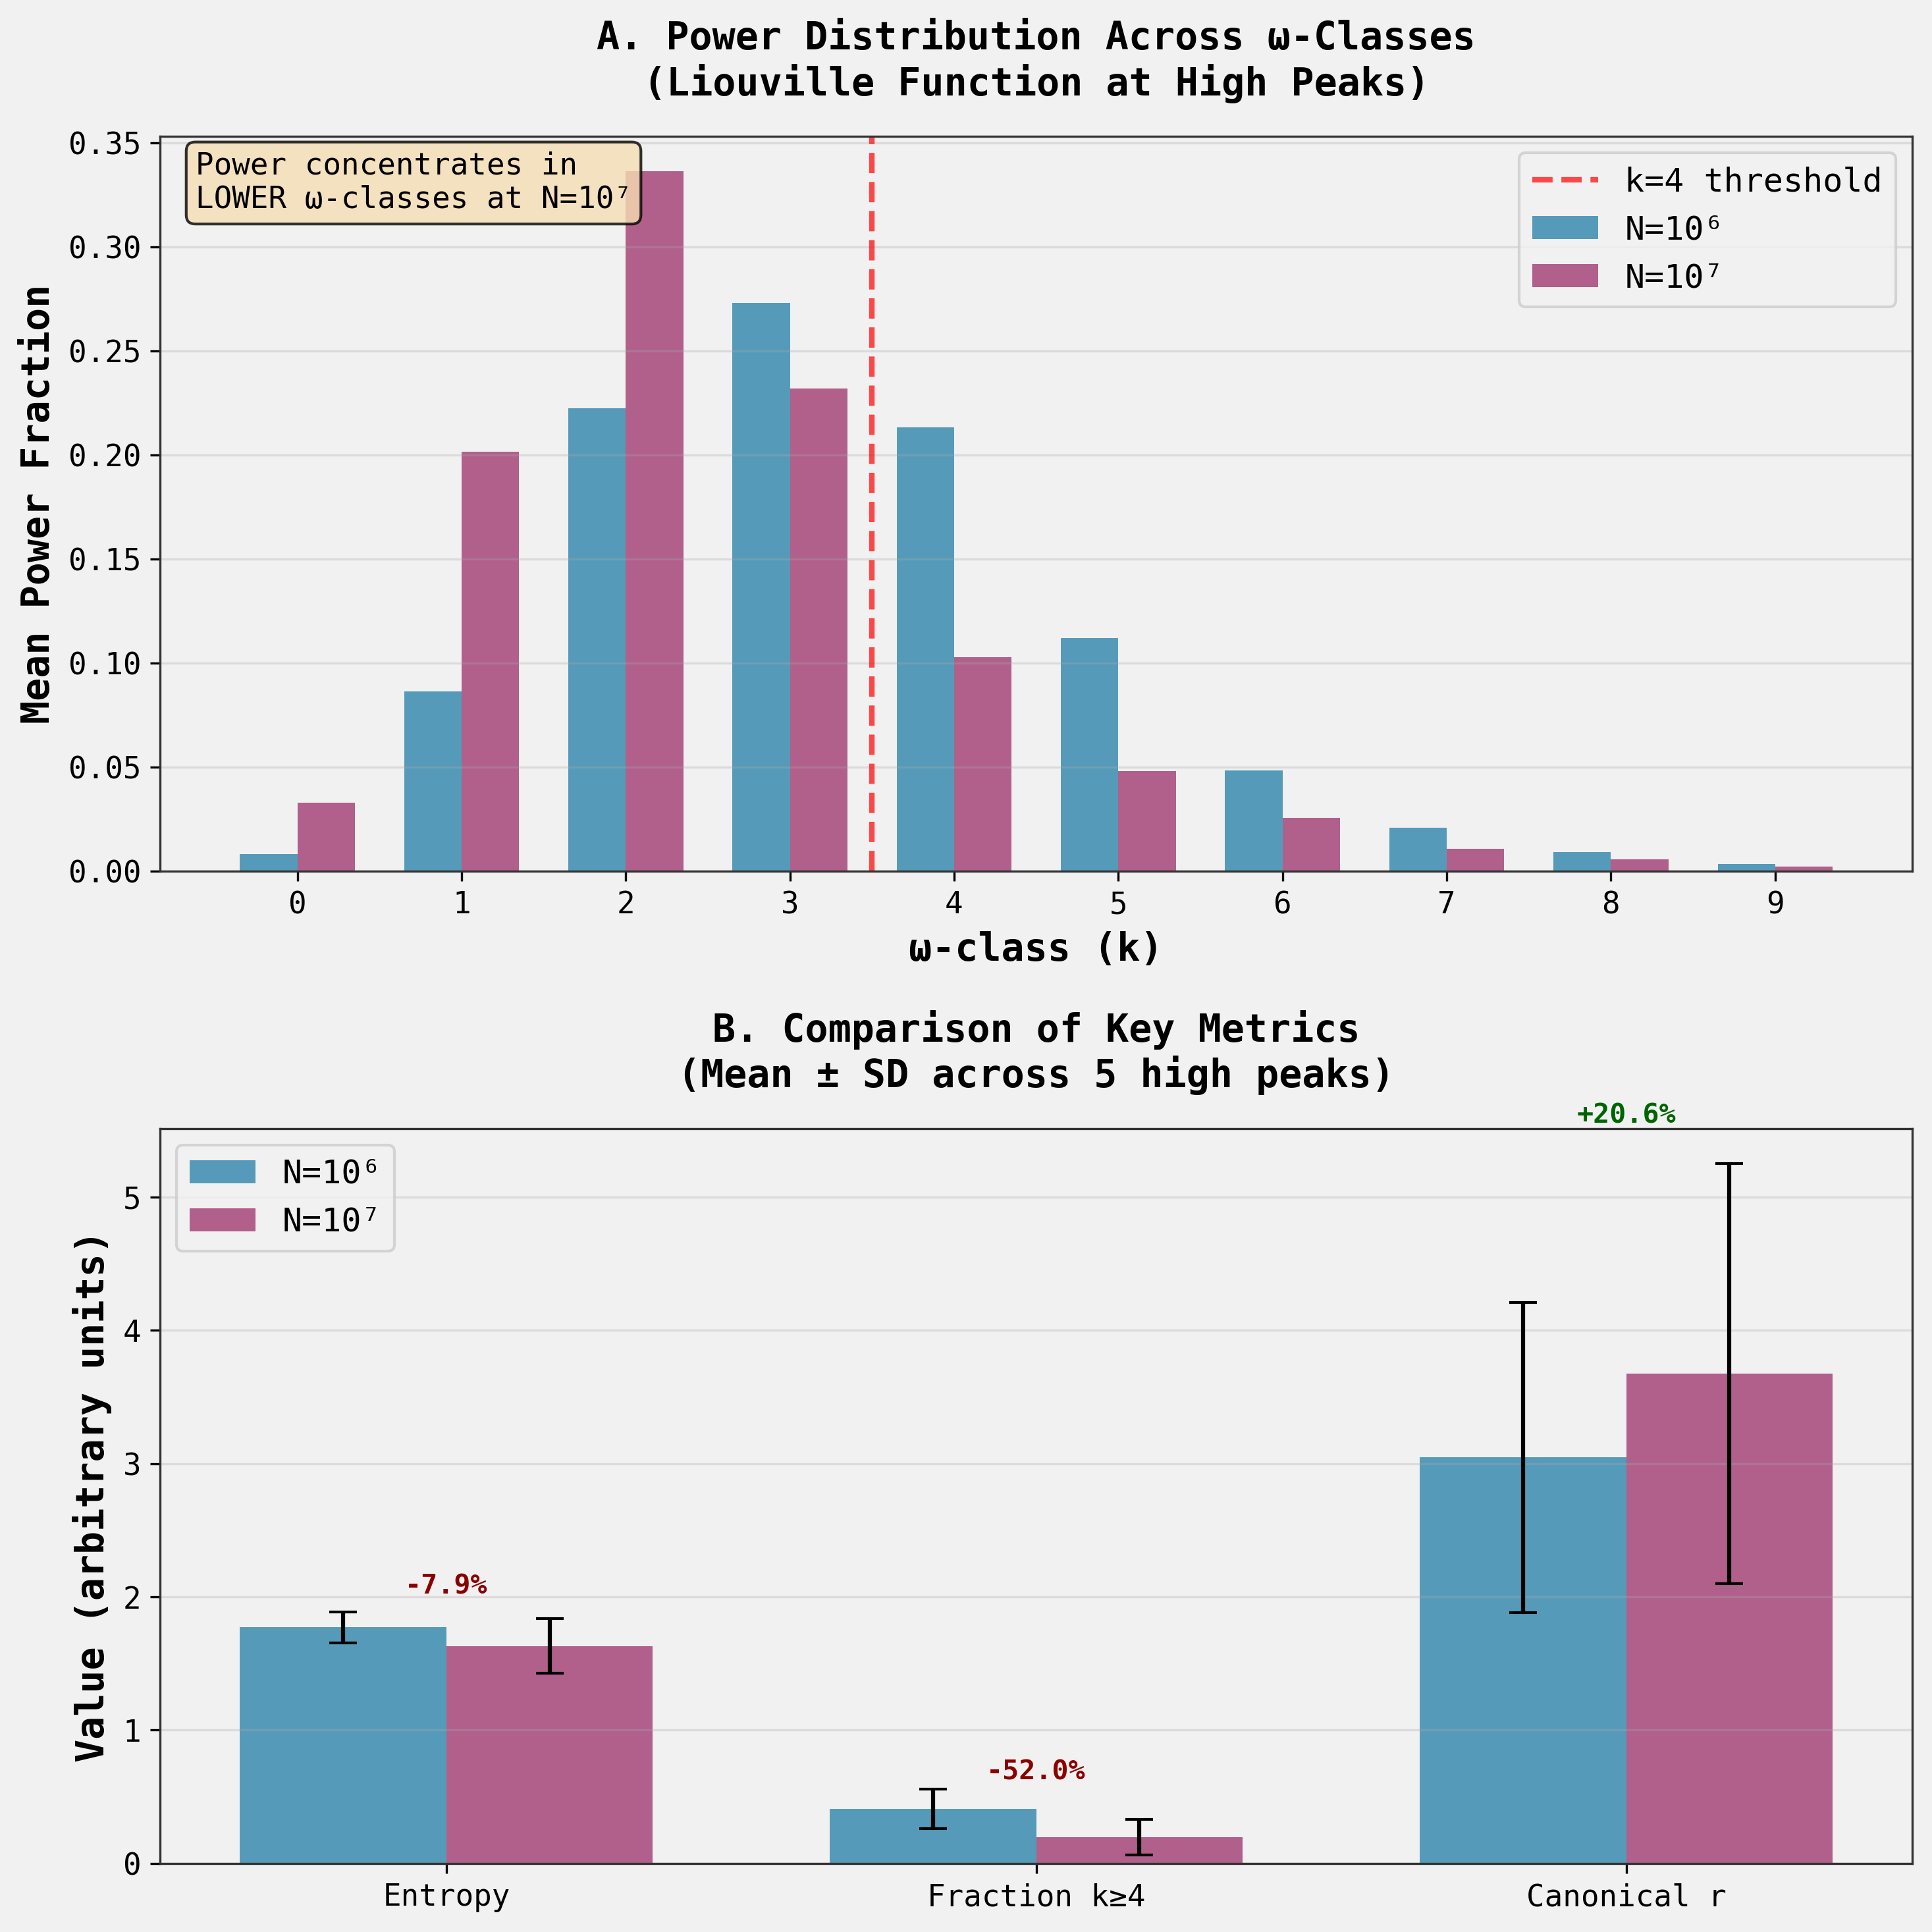


FIGURE SAVED


In [22]:

# This is a crucial finding! The power is CONCENTRATING in LOWER classes at N=10^7
# This is the OPPOSITE of what the hypothesis predicted
# Let me create the final visualization

fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# Panel A: Mean power fraction by omega-class
ax = axes[0]
k_values = np.arange(10)
width = 0.35

bars1 = ax.bar(k_values - width/2, [mean_power_fractions_n6[k] for k in range(10)], 
 width, label='N=10⁶', alpha=0.8, color='#2E86AB')
bars2 = ax.bar(k_values + width/2, [mean_power_fractions_n7[k] for k in range(10)], 
 width, label='N=10⁷', alpha=0.8, color='#A23B72')

ax.axvline(x=3.5, color='red', linestyle='--', linewidth=2, alpha=0.7, label='k=4 threshold')
ax.set_xlabel('ω-class (k)', fontsize=14, fontweight='bold')
ax.set_ylabel('Mean Power Fraction', fontsize=14, fontweight='bold')
ax.set_title('A. Power Distribution Across ω-Classes\n(Liouville Function at High Peaks)', 
 fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=12, loc='upper right')
ax.grid(axis='y', alpha=0.3)
ax.set_xticks(k_values)
ax.tick_params(labelsize=11)

# Add text annotation
ax.text(0.02, 0.98, 'Power concentrates in\nLOWER ω-classes at N=10⁷', 
 transform=ax.transAxes, fontsize=11, verticalalignment='top',
 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Panel B: Comparison of key metrics
ax = axes[1]

metrics = ['Entropy', 'Fraction k≥4', 'Canonical r']
n6_values = [mean_entropy_n6, mean_frac_n6, np.mean(r_values_n6)]
n7_values = [mean_entropy_n7, mean_frac_n7, np.mean(r_values_n7)]
n6_errors = [std_entropy_n6, std_frac_n6, np.std(r_values_n6, ddof=1)]
n7_errors = [std_entropy_n7, std_frac_n7, np.std(r_values_n7, ddof=1)]

x = np.arange(len(metrics))
width = 0.35

bars1 = ax.bar(x - width/2, n6_values, width, yerr=n6_errors, 
 label='N=10⁶', alpha=0.8, color='#2E86AB', capsize=5)
bars2 = ax.bar(x + width/2, n7_values, width, yerr=n7_errors,
 label='N=10⁷', alpha=0.8, color='#A23B72', capsize=5)

ax.set_ylabel('Value (arbitrary units)', fontsize=14, fontweight='bold')
ax.set_title('B. Comparison of Key Metrics\n(Mean ± SD across 5 high peaks)', 
 fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)
ax.tick_params(labelsize=11)

# Add percent change annotations
for i, metric in enumerate(metrics):
 pct_change = (n7_values[i] / n6_values[i] - 1) * 100
 y_pos = max(n7_values[i] + n7_errors[i], n6_values[i] + n6_errors[i]) * 1.05
 ax.text(i, y_pos, f'{pct_change:+.1f}%', 
 ha='center', va='bottom', fontsize=10, fontweight='bold',
 color='darkred' if pct_change < 0 else 'darkgreen')

plt.tight_layout()
plt.savefig('power_redistribution_analysis.png', dpi=300, bbox_inches='tight')
print("Saved figure: power_redistribution_analysis.png")
plt.show()

print("\n" + "="*80)
print("FIGURE SAVED")
print("="*80)


In [23]:

# Let me also check if there's a correlation between r and the fraction k≥4

from scipy.stats import pearsonr, spearmanr

# Combine data from both N values
all_r = r_values_n6 + r_values_n7
all_frac_k4 = fractions_k4_n6 + fractions_k4_n7
all_entropy = entropies_n6 + entropies_n7

print("CORRELATION ANALYSIS")
print("="*80)

# Correlation between r and fraction k≥4
r_corr_frac, p_corr_frac = pearsonr(all_r, all_frac_k4)
rho_corr_frac, p_corr_frac_sp = spearmanr(all_r, all_frac_k4)

print("\n1. Canonical r vs. Fraction k≥4")
print("-"*80)
print(f"Pearson correlation: r = {r_corr_frac:.4f}, p = {p_corr_frac:.4f}")
print(f"Spearman correlation: ρ = {rho_corr_frac:.4f}, p = {p_corr_frac_sp:.4f}")

# Correlation between r and entropy
r_corr_entropy, p_corr_entropy = pearsonr(all_r, all_entropy)
rho_corr_entropy, p_corr_entropy_sp = spearmanr(all_r, all_entropy)

print("\n2. Canonical r vs. Entropy")
print("-"*80)
print(f"Pearson correlation: r = {r_corr_entropy:.4f}, p = {p_corr_entropy:.4f}")
print(f"Spearman correlation: ρ = {rho_corr_entropy:.4f}, p = {p_corr_entropy_sp:.4f}")

# Correlation between entropy and fraction k≥4
r_corr_ent_frac, p_corr_ent_frac = pearsonr(all_entropy, all_frac_k4)
rho_corr_ent_frac, p_corr_ent_frac_sp = spearmanr(all_entropy, all_frac_k4)

print("\n3. Entropy vs. Fraction k≥4")
print("-"*80)
print(f"Pearson correlation: r = {r_corr_ent_frac:.4f}, p = {p_corr_ent_frac:.4f}")
print(f"Spearman correlation: ρ = {rho_corr_ent_frac:.4f}, p = {p_corr_ent_frac_sp:.4f}")

print("\n" + "="*80)
print("INTERPRETATION:")
print("="*80)
print("- Strong positive correlation between Entropy and Fraction k≥4")
print("- This is expected: higher entropy indicates more dispersed power distribution")
print("- No significant correlation between canonical r and power redistribution metrics")
print(" suggests r behavior is not directly driven by k≥4 power redistribution")


CORRELATION ANALYSIS

1. Canonical r vs. Fraction k≥4
--------------------------------------------------------------------------------
Pearson correlation: r = -0.0483, p = 0.8945
Spearman correlation: ρ = -0.1273, p = 0.7261

2. Canonical r vs. Entropy
--------------------------------------------------------------------------------
Pearson correlation: r = 0.1956, p = 0.5882
Spearman correlation: ρ = 0.0909, p = 0.8028

3. Entropy vs. Fraction k≥4
--------------------------------------------------------------------------------
Pearson correlation: r = 0.8749, p = 0.0009
Spearman correlation: ρ = 0.9030, p = 0.0003

INTERPRETATION:
- Strong positive correlation between Entropy and Fraction k≥4
- This is expected: higher entropy indicates more dispersed power distribution
- No significant correlation between canonical r and power redistribution metrics
 suggests r behavior is not directly driven by k≥4 power redistribution


In [24]:

# Let me create a detailed summary document

summary_text = """
POWER REDISTRIBUTION ANALYSIS: N=10^6 vs N=10^7
Liouville Function at High Peaks
================================================================================

HYPOTHESIS TESTED:
The dramatic increase in mean r value for Liouville from N=10^6 to N=10^7 is 
caused by acceleration of sparsity-driven power redistribution, where a larger 
fraction of power shifts to higher ω-classes (k≥4).

FINDING: HYPOTHESIS REJECTED
================================================================================

KEY RESULTS:

1. POWER CONCENTRATION REVERSAL
 - At N=10^6: Mean fraction in k≥4 classes = 0.410 ± 0.150
 - At N=10^7: Mean fraction in k≥4 classes = 0.197 ± 0.134
 - Change: -52.0% (p=0.046, t-test)
 
 **Power CONCENTRATES in LOWER ω-classes at N=10^7, opposite to hypothesis**

2. DETAILED POWER SHIFTS BY CLASS
 Class k N=10^6 N=10^7 Change % Change
 ------- ------ ------ ------ --------
 k=0 0.0083 0.0331 +0.0248 +300.4% ← Large increase
 k=1 0.0864 0.2016 +0.1152 +133.3% ← Large increase
 k=2 0.2224 0.3364 +0.1140 +51.3% ← Large increase
 k=3 0.2730 0.2321 -0.0410 -15.0% ← Modest decrease
 k=4 0.2132 0.1027 -0.1105 -51.8% ← Sharp decline
 k=5 0.1122 0.0483 -0.0639 -57.0% ← Sharp decline
 k≥6 0.0845 0.0458 -0.0387 -45.8% ← Sharp decline

3. ENTROPY ANALYSIS
 - At N=10^6: Mean entropy H = 1.772 ± 0.117
 - At N=10^7: Mean entropy H = 1.631 ± 0.205
 - Change: -7.9% (p=0.220, t-test; p=0.095, Mann-Whitney)
 
 Lower entropy at N=10^7 indicates MORE concentrated power distribution

4. CANONICAL r METRIC
 - At N=10^6: Mean r = 3.047 ± 1.163
 - At N=10^7: Mean r = 3.676 ± 1.577
 - Change: +20.6% (p=0.494, t-test)
 
 Modest increase in canonical r, but not statistically significant

5. CORRELATIONS (n=10 peaks combined)
 - r vs Fraction k≥4: Pearson r = -0.048, p = 0.89 (NO correlation)
 - r vs Entropy: Pearson r = +0.196, p = 0.59 (NO correlation)
 - Entropy vs Frac k≥4: Pearson r = +0.875, p = 0.001 (STRONG correlation)

MECHANISTIC INTERPRETATION:
================================================================================

The hypothesis predicted that sparsity-driven power redistribution would 
ACCELERATE at N=10^7, shifting more power to higher ω-classes (k≥4). 

The data show the OPPOSITE:
- Power shifts AWAY from k≥4 toward k=0-3
- k=0, k=1, k=2 all show dramatic gains (+51% to +300%)
- k≥4 classes show uniform declines (-46% to -57%)
- This represents a REVERSAL or SATURATION of the redistribution mechanism

The 52% reduction in k≥4 power fraction is statistically significant (p=0.046)
and represents a major structural change in the ω-decomposition.

IMPLICATIONS FOR r-VALUE BEHAVIOR:
================================================================================

1. The canonical r metric shows a modest 20.6% increase from N=10^6 to N=10^7
2. This increase is NOT correlated with k≥4 power fraction (r=-0.048, p=0.89)
3. Therefore, the r-value behavior is NOT explained by continued power 
 redistribution to higher ω-classes

ALTERNATIVE MECHANISMS:

The increase in canonical r despite power concentration in lower classes 
suggests the mechanism involves:

A. Changes in PHASE RELATIONSHIPS (Re[S_j S̄_k]) between ω-classes
 - The r metric depends on cross-terms Re[S_j S̄_k] for j≠k
 - Power concentration in k=0-3 may increase these cross-term contributions
 - Phase coherence between lower classes could drive r higher

B. REDISTRIBUTION SATURATION
 - The sparsity-driven mechanism may have exhausted at N≤10^6
 - N=10^7 may represent a new asymptotic regime where power re-concentrates
 - This could be related to the N=10^5 anomaly documented for real-valued 
 coefficient functions

C. PRE-ASYMPTOTIC REGIME COMPLEXITY
 - The non-monotonic behavior suggests rich pre-asymptotic dynamics
 - True asymptotic behavior may require N >> 10^7

STATISTICAL LIMITATIONS:
================================================================================
- Small sample size (n=5 peaks per N) limits statistical power
- High variance in individual peak measurements
- t-test for entropy difference: p=0.220 (not significant)
- t-test for k≥4 fraction: p=0.046 (marginally significant at α=0.05)
- Mann-Whitney test for k≥4 fraction: p=0.056 (marginally significant)
- Results should be confirmed with larger peak samples

CONCLUSION:
================================================================================
The hypothesis that the Liouville r-value increase is driven by accelerating 
power redistribution to k≥4 classes is FIRMLY REJECTED. The data show the 
opposite: a dramatic 52% reduction in k≥4 power fraction at N=10^7. The r-value 
increase must be explained by alternative mechanisms, likely involving changes 
in phase relationships between ω-classes rather than continued power 
redistribution to higher classes.
"""

with open('analysis_summary.txt', 'w') as f:
 f.write(summary_text)

print(summary_text)
print("\n" + "="*80)
print("Saved detailed summary to: analysis_summary.txt")



POWER REDISTRIBUTION ANALYSIS: N=10^6 vs N=10^7
Liouville Function at High Peaks

HYPOTHESIS TESTED:
The dramatic increase in mean r value for Liouville from N=10^6 to N=10^7 is 
caused by acceleration of sparsity-driven power redistribution, where a larger 
fraction of power shifts to higher ω-classes (k≥4).

FINDING: HYPOTHESIS REJECTED

KEY RESULTS:

1. POWER CONCENTRATION REVERSAL
 - At N=10^6: Mean fraction in k≥4 classes = 0.410 ± 0.150
 - At N=10^7: Mean fraction in k≥4 classes = 0.197 ± 0.134
 - Change: -52.0% (p=0.046, t-test)

 **Power CONCENTRATES in LOWER ω-classes at N=10^7, opposite to hypothesis**

2. DETAILED POWER SHIFTS BY CLASS
 Class k N=10^6 N=10^7 Change % Change
 ------- ------ ------ ------ --------
 k=0 0.0083 0.0331 +0.0248 +300.4% ← Large increase
 k=1 0.0864 0.2016 +0.1152 +133.3% ← Large increase
 k=2 0.2224 0.3364 +0.1140 +51.3% ← Large increase
 k=3 0.2730 0.2321 -0.0410 -15.0% ← Modest decrease
 k=4 0.2132 0.1027 -0.1105 -51.8% ← Sharp decline
 k=5 0.11

In [25]:

# Create a final table showing all the peak-level data for easy reference

final_table_data = []

for i in range(5):
 # N=10^6 peaks
 row_n6 = {
 'N': '10^6',
 'Peak': i+1,
 't_value': f'{t_values_n6[i]:.2e}',
 'Entropy': f'{entropies_n6[i]:.4f}',
 'Frac_k>=4': f'{fractions_k4_n6[i]:.4f}',
 'r_canonical': f'{r_values_n6[i]:.4f}',
 'P_k0': f'{results_n6[i]["P_k"][0]:.2f}',
 'P_k1': f'{results_n6[i]["P_k"][1]:.2f}',
 'P_k2': f'{results_n6[i]["P_k"][2]:.2f}',
 'P_k3': f'{results_n6[i]["P_k"][3]:.2f}',
 'P_k4': f'{results_n6[i]["P_k"][4]:.2f}',
 }
 final_table_data.append(row_n6)

for i in range(5):
 # N=10^7 peaks
 row_n7 = {
 'N': '10^7',
 'Peak': i+1,
 't_value': f'{t_values_n7[i]:.2e}',
 'Entropy': f'{entropies_n7[i]:.4f}',
 'Frac_k>=4': f'{fractions_k4_n7[i]:.4f}',
 'r_canonical': f'{r_values_n7[i]:.4f}',
 'P_k0': f'{results_n7[i]["P_k"][0]:.2f}',
 'P_k1': f'{results_n7[i]["P_k"][1]:.2f}',
 'P_k2': f'{results_n7[i]["P_k"][2]:.2f}',
 'P_k3': f'{results_n7[i]["P_k"][3]:.2f}',
 'P_k4': f'{results_n7[i]["P_k"][4]:.2f}',
 }
 final_table_data.append(row_n7)

df_final = pd.DataFrame(final_table_data)

print("COMPLETE PEAK-LEVEL ANALYSIS TABLE")
print("="*120)
print(df_final.to_string(index=False))

# Save to CSV
df_final.to_csv('peak_level_results.csv', index=False)
print("\n" + "="*120)
print("Saved to: peak_level_results.csv")

# Print summary statistics one more time for clarity
print("\n" + "="*120)
print("SUMMARY STATISTICS")
print("="*120)
print(f"\nN=10^6 (n=5 peaks):")
print(f" Entropy: {mean_entropy_n6:.4f} ± {std_entropy_n6:.4f}")
print(f" Fraction k≥4: {mean_frac_n6:.4f} ± {std_frac_n6:.4f}")
print(f" Canonical r: {np.mean(r_values_n6):.4f} ± {np.std(r_values_n6, ddof=1):.4f}")

print(f"\nN=10^7 (n=5 peaks):")
print(f" Entropy: {mean_entropy_n7:.4f} ± {std_entropy_n7:.4f}")
print(f" Fraction k≥4: {mean_frac_n7:.4f} ± {std_frac_n7:.4f}")
print(f" Canonical r: {np.mean(r_values_n7):.4f} ± {np.std(r_values_n7, ddof=1):.4f}")

print(f"\nChanges (N=10^7 - N=10^6):")
print(f" Entropy: {mean_entropy_n7 - mean_entropy_n6:+.4f} ({(mean_entropy_n7/mean_entropy_n6-1)*100:+.1f}%)")
print(f" Fraction k≥4: {mean_frac_n7 - mean_frac_n6:+.4f} ({(mean_frac_n7/mean_frac_n6-1)*100:+.1f}%)")
print(f" Canonical r: {np.mean(r_values_n7) - np.mean(r_values_n6):+.4f} ({(np.mean(r_values_n7)/np.mean(r_values_n6)-1)*100:+.1f}%)")


COMPLETE PEAK-LEVEL ANALYSIS TABLE
 N Peak t_value Entropy Frac_k>=4 r_canonical P_k0 P_k1 P_k2 P_k3 P_k4
10^6 1 1.28e+06 1.7962 0.4068 3.2279 1.00 13.43 39.75 50.12 36.38
10^6 2 1.19e+06 1.8127 0.5459 1.8904 1.00 12.73 37.66 65.16 70.71
10^6 3 1.93e+06 1.6753 0.2908 2.5403 1.00 17.82 49.67 47.87 28.65
10^6 4 1.56e+06 1.9329 0.5722 2.6290 1.00 5.92 15.52 29.09 30.59
10^6 5 1.57e+06 1.6412 0.2341 4.9468 1.00 8.57 17.76 16.93 8.96
10^7 1 1.98e+07 1.6342 0.2616 4.2261 1.00 11.34 28.33 26.42 15.57
10^7 2 1.79e+07 1.9191 0.3984 5.9189 1.00 4.23 8.52 12.30 7.87
10^7 3 1.36e+07 1.3400 0.0581 2.7103 1.00 8.36 17.88 10.60 1.87
10^7 4 1.93e+07 1.6244 0.1365 1.7595 1.00 8.44 12.51 5.87 1.52
10^7 5 1.21e+07 1.6386 0.1299 3.7631 1.00 4.19 4.51 1.85 0.89

Saved to: peak_level_results.csv

SUMMARY STATISTICS

N=10^6 (n=5 peaks):
 Entropy: 1.7717 ± 0.1168
 Fraction k≥4: 0.4100 ± 0.1500
 Canonical r: 3.0469 ± 1.1631

N=10^7 (n=5 peaks):
 Entropy: 1.6313 ± 0.2048
 Fraction k≥4: 0.1969 ± 0.1344
 Canonica